# 02 — De la señal a una tabla

Convierte 153 archivos EDF en una tabla. Una fila por noche.

```
7.950.000 números   la señal de una noche
      721 épocas    de 30 segundos
      721 espectros uno por época
        5 curvas    una por fase del sueño
       60 números   12 por fase
```

Cada paso es una función. Se prueba con una noche y al final se aplica a las 153.

In [1]:
import glob, os, time
from pathlib import Path

import matplotlib.pyplot as plt
import mne, numpy as np, pandas as pd
from scipy.signal import welch

mne.set_log_level("ERROR")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.axisbelow": True, "font.size": 9})

RAIZ = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "Data").is_dir())
DATA_DIR = RAIZ / "Data" / "sleep-cassette"
CANAL, EPOCA_S = "EEG Fpz-Cz", 30      # canal del recorrido de ejemplo
CANALES = ["EEG Fpz-Cz", "EEG Pz-Oz"]  # los dos que se procesan al final


def ruta_salida(canal):
    """El nombre del archivo sale del canal, para que no puedan sobrescribirse."""
    return Path(f'datos/caracteristicas_noche_{canal.replace("EEG ", "").replace("-", "")}.csv')
BANDAS = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 12),
          "sigma": (12, 16), "beta": (16, 30)}
RANGO = (0.5, 30)

ETAPAS = {"Sleep stage W": "W", "Sleep stage 1": "N1", "Sleep stage 2": "N2",
          "Sleep stage 3": "N3", "Sleep stage 4": "N3", "Sleep stage R": "REM",
          "Movement time": "M", "Sleep stage ?": "?"}
DORMIDO = ["N1", "N2", "N3", "REM"]
FASES = ["W_sleep", "N1", "N2", "N3", "REM"]
COLOR = {"W_sleep": "#2a78d6", "N1": "#eb6834", "N2": "#1baf7a",
         "N3": "#eda100", "REM": "#e87ba4"}
TINTA, GRIS = "#3a3a3a", "#8a8a8a"

## 1 · Cargar la noche

Dos archivos: la señal y las anotaciones del técnico. El técnico miró la noche en
trozos de 30 segundos y anotó la fase de cada uno.

In [2]:
def cargar_noche(codigo):
    """Devuelve la señal y una fila por época de 30 s con su fase."""
    psg = str(DATA_DIR / f"{codigo}-PSG.edf")
    hyp = glob.glob(str(DATA_DIR / f"{codigo[:6]}*-Hypnogram.edf"))[0]

    raw = mne.io.read_raw_edf(psg, preload=False)
    fs = raw.info["sfreq"]
    duracion = raw.n_times / fs

    ann = mne.read_annotations(hyp)
    epocas = [{"inicio_s": o + EPOCA_S * k, "stage": ETAPAS.get(d, "?")}
              for o, dur, d in zip(ann.onset, ann.duration, ann.description)
              for k in range(int(dur // EPOCA_S))
              if o + EPOCA_S * k + EPOCA_S <= duracion]   # descarta lo que no tiene señal

    return raw, fs, pd.DataFrame(epocas)


raw, fs, epocas = cargar_noche("SC4001E0")
print(f"{len(epocas)} épocas de 30 s")
print(epocas.stage.value_counts().to_string())

2650 épocas de 30 s
stage
W      1997
N2      250
N3      220
REM     125
N1       58


## 2 · Quitar la vigilia diurna

El registro dura un día entero, así que casi todo es W. Nos quedamos con el tramo
entre la primera y la última época de sueño.

La W de **dentro** se queda: son despertares nocturnos, y eso sí es información.

In [3]:
def recortar(epocas):
    """Del primer al último sueño. La W de dentro pasa a llamarse W_sleep."""
    dormido = epocas.stage.isin(DORMIDO).values
    if not dormido.any():
        return None
    i, j = np.where(dormido)[0][[0, -1]]
    noche = epocas.iloc[i:j + 1].copy()
    noche["stage"] = noche.stage.replace({"W": "W_sleep"})
    return noche


noche = recortar(epocas)
print(f"{len(epocas)} épocas  ->  {len(noche)}")
print(noche.stage.value_counts().to_string())

2650 épocas  ->  721
stage
N2         250
N3         220
REM        125
W_sleep     68
N1          58


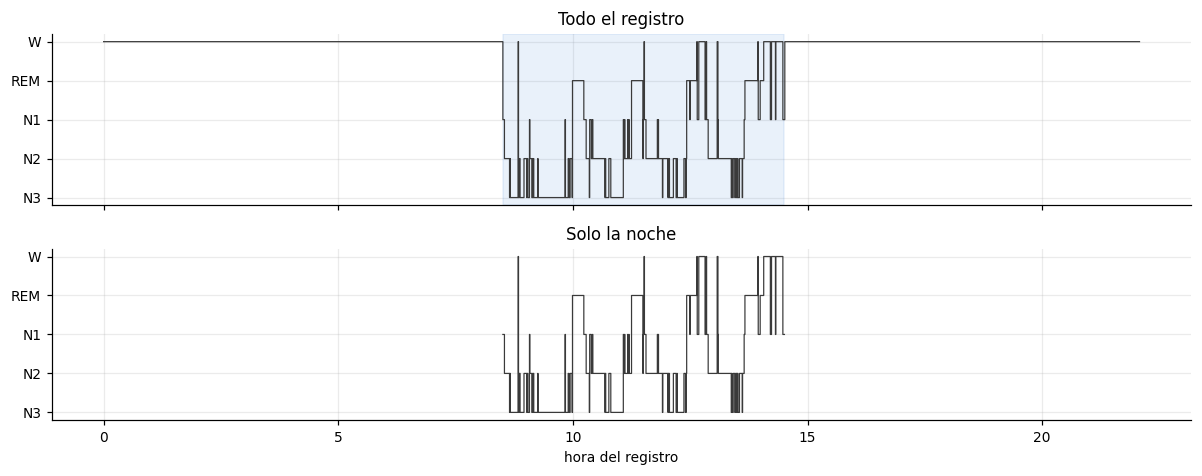

In [4]:
orden = {"W": 4, "W_sleep": 4, "REM": 3, "N1": 2, "N2": 1, "N3": 0}
fig, ejes = plt.subplots(2, 1, figsize=(11, 4.4), sharex=True)

for eje, (datos, titulo) in zip(ejes, [(epocas, "Todo el registro"),
                                       (noche, "Solo la noche")]):
    eje.step(datos.inicio_s / 3600, datos.stage.map(orden), where="post",
             lw=.8, color=TINTA)
    eje.set(yticks=range(5), yticklabels=["N3", "N2", "N1", "REM", "W"], title=titulo)

ejes[0].axvspan(noche.inicio_s.iloc[0]/3600, noche.inicio_s.iloc[-1]/3600,
                color="#2a78d6", alpha=.10)
ejes[1].set_xlabel("hora del registro")
plt.tight_layout(); plt.show()

## 3 · Una época → un espectro

Una época son 30 s × 100 muestras/s = **3.000 números**. La transformada de Fourier
los convierte en un espectro: cuánta energía hay en cada frecuencia.

In [5]:
def espectro(senal_epoca, fs):
    """3.000 números -> (frecuencias, energía)."""
    frecs, psd = welch(senal_epoca, fs=fs, nperseg=int(4 * fs))
    return frecs, psd * 1e12


t = noche[noche.stage == "N2"].inicio_s.iloc[20]
sig = raw.get_data(picks=[CANAL], start=int(t*fs), stop=int((t+EPOCA_S)*fs))[0]
frecs, psd = espectro(sig, fs)
print(f"{len(sig):,} números  ->  {len(psd)} números (0 a 50 Hz, cada 0,25)")

3,000 números  ->  201 números (0 a 50 Hz, cada 0,25)


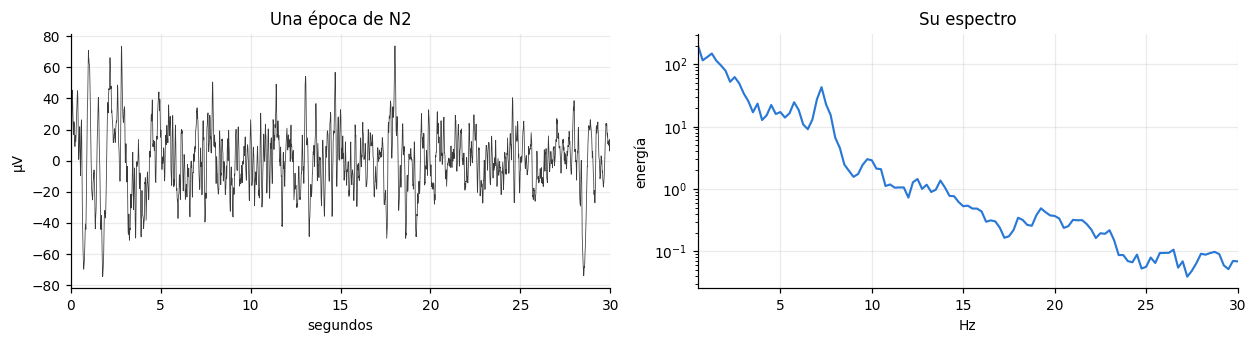

In [6]:
m = (frecs >= RANGO[0]) & (frecs <= RANGO[1])
fig, ejes = plt.subplots(1, 2, figsize=(11.5, 3.2))
ejes[0].plot(np.arange(len(sig))/fs, sig*1e6, lw=.5, color=TINTA)
ejes[0].set(xlabel="segundos", ylabel="µV", xlim=(0, 30), title="Una época de N2")
ejes[1].semilogy(frecs[m], psd[m], lw=1.4, color="#2a78d6")
ejes[1].set(xlabel="Hz", ylabel="energía", xlim=RANGO, title="Su espectro")
plt.tight_layout(); plt.show()

## 4 · Agrupar por fase y promediar

Se calcula el espectro de las 721 épocas. Luego se agrupan por fase y se promedian
**Hz a Hz**: 250 curvas de N2 entran, una sale.

In [7]:
def espectros_por_fase(raw, noche, fs, canal=None):
    """Una curva promedio por fase. Devuelve (frecuencias, {fase: curva}, conteo)."""
    ini = noche.inicio_s.iloc[0]
    fin = noche.inicio_s.iloc[-1] + EPOCA_S
    senal = raw.get_data(picks=[canal or CANAL], start=int(ini*fs),
                     stop=int(fin*fs))[0]

    n = int(EPOCA_S * fs)
    psds, fases = [], []
    for _, ep in noche.iterrows():
        d = int((ep.inicio_s - ini) * fs)
        trozo = senal[d:d + n]
        if len(trozo) == n:
            frecs, p = espectro(trozo, fs)
            psds.append(p); fases.append(ep.stage)

    psds, fases = np.array(psds), np.array(fases)
    curvas = {f: psds[fases == f].mean(0) for f in FASES if (fases == f).any()}
    conteo = {f: int((fases == f).sum()) for f in FASES}
    return frecs, curvas, conteo, psds, fases


frecs, curvas, conteo, psds, fases = espectros_por_fase(raw, noche, fs)
print(f"{len(psds)} espectros  ->  {len(curvas)} curvas promedio")
print(conteo)

721 espectros  ->  5 curvas promedio
{'W_sleep': 68, 'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125}


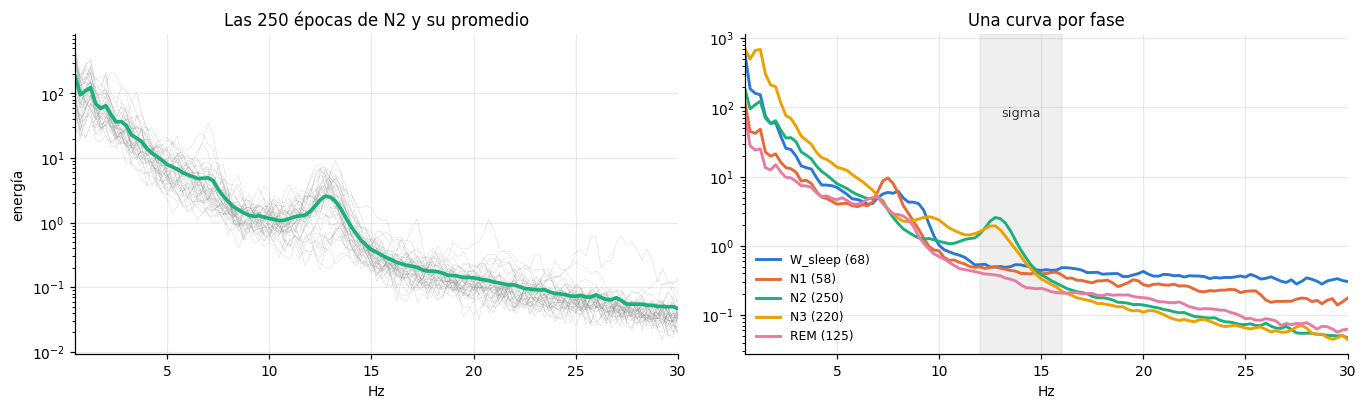

In [8]:
m = (frecs >= RANGO[0]) & (frecs <= RANGO[1])
fig, ejes = plt.subplots(1, 2, figsize=(12.5, 3.8))

for c in psds[fases == "N2"][::6]:
    ejes[0].semilogy(frecs[m], c[m], lw=.3, color=GRIS, alpha=.35)
ejes[0].semilogy(frecs[m], curvas["N2"][m], lw=2.4, color=COLOR["N2"])
ejes[0].set(xlabel="Hz", ylabel="energía", xlim=RANGO,
            title=f"Las {conteo['N2']} épocas de N2 y su promedio")

for f, c in curvas.items():
    ejes[1].semilogy(frecs[m], c[m], lw=1.9, color=COLOR[f], label=f"{f} ({conteo[f]})")
ejes[1].axvspan(12, 16, color=GRIS, alpha=.13)
ejes[1].annotate("sigma", xy=(14, curvas["N2"][m].max()*.4), ha="center",
                 fontsize=8.5, color=TINTA)
ejes[1].set(xlabel="Hz", xlim=RANGO, title="Una curva por fase")
ejes[1].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

Las cinco curvas no se parecen. En la banda sigma —donde están los husos de sueño—
N2 destaca sobre las demás. Eso es lo que se pierde al promediar toda la noche junta.

## 5 · De una curva a 12 números

De las 201 frecuencias nos quedamos con las de 0,5 a 30 Hz: **119**. Se agrupan en
cinco bandas sumando la energía, y de ahí salen 12 números:

- **5 absolutos** — la energía de cada banda
- **5 relativos** — esa energía dividida por el total, o sea qué porcentaje ocupa
- **potencia total** — la suma de las 119
- **SEF95** — la frecuencia por debajo de la cual está el 95 % de la energía

In [9]:
def doce_numeros(curva, frecs):
    """Una curva -> 12 números."""
    m = (frecs >= RANGO[0]) & (frecs <= RANGO[1])
    total = curva[m].sum()

    f = {"potencia_total_log": np.log10(total)}
    for nombre, (a, b) in BANDAS.items():
        p = curva[(frecs >= a) & (frecs < b)].sum()
        f[f"abs_{nombre}"] = np.log10(p)
        f[f"rel_{nombre}"] = p / total
    acum = np.cumsum(curva[m])
    f["sef95"] = frecs[m][np.argmax(acum >= .95 * acum[-1])]
    return f


n2 = doce_numeros(curvas["N2"], frecs)
pd.Series(n2).round(4).to_frame("N2")

,N2
potencia_total_log,3.0325
abs_delta,2.9642
rel_delta,0.8546
abs_theta,2.0396
rel_theta,0.1017
abs_alpha,1.3295
rel_alpha,0.0198
abs_sigma,1.2893
rel_sigma,0.0181
abs_beta,0.7972


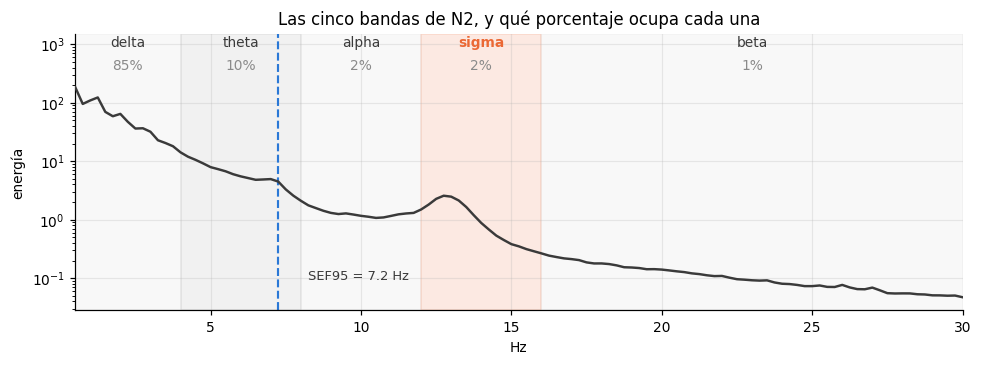

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for i, (nombre, (a, b)) in enumerate(BANDAS.items()):
    sigma = nombre == "sigma"
    ax.axvspan(a, b, color="#eb6834" if sigma else TINTA,
               alpha=.14 if sigma else (.07 if i % 2 else .03), zorder=0)
    ax.text((a+b)/2, curvas["N2"][m].max()*5, nombre, ha="center", fontsize=9,
            color="#eb6834" if sigma else TINTA, weight="bold" if sigma else "normal")
    ax.text((a+b)/2, curvas["N2"][m].max()*2, f"{n2[f'rel_{nombre}']*100:.0f}%",
            ha="center", fontsize=9, color=GRIS)

ax.semilogy(frecs[m], curvas["N2"][m], lw=1.6, color=TINTA, zorder=3)
ax.axvline(n2["sef95"], color="#2a78d6", ls="--", lw=1.4)
ax.annotate(f"SEF95 = {n2['sef95']:.1f} Hz", xy=(n2["sef95"]+1, curvas['N2'][m].min()*2),
            fontsize=8.5, color=TINTA)
ax.set(xlabel="Hz", ylabel="energía", xlim=RANGO,
       ylim=(curvas["N2"][m].min()*.6, curvas["N2"][m].max()*8),
       title="Las cinco bandas de N2, y qué porcentaje ocupa cada una")
plt.tight_layout(); plt.show()

Como esto se hace para las cinco fases: **12 × 5 = 60 números por noche**.

## 6 · La arquitectura del sueño

Ocho números más, que salen de **contar el hipnograma**. Nada de señal ni de Fourier.

In [11]:
def arquitectura(noche):
    """Cuenta épocas del hipnograma -> 8 números. No usa la señal para nada."""
    c = noche.stage.value_counts()
    dormido = sum(c.get(e, 0) for e in DORMIDO)      # todo menos W_sleep
    rem = noche[noche.stage == "REM"]

    arq = {
        "horas_dormidas":    dormido * EPOCA_S / 3600,
        "eficiencia":        dormido / len(noche),           # dormido / tiempo en cama
        "minutos_despierto": c.get("W_sleep", 0) * EPOCA_S / 60,
        "minutos_hasta_rem": ((rem.inicio_s.min() - noche.inicio_s.iloc[0]) / 60
                              if len(rem) else np.nan),
    }
    for e in DORMIDO:                                 # % del SUEÑO en cada fase
        arq[f"pct_sueno_en_{e}"] = c.get(e, 0) / dormido * 100 if dormido else np.nan
    return arq


pd.Series(arquitectura(noche)).round(2).to_frame("valor")

,valor
horas_dormidas,5.44
eficiencia,0.91
minutos_despierto,34.00
minutos_hasta_rem,89.00
pct_sueno_en_N1,8.88
pct_sueno_en_N2,38.28
pct_sueno_en_N3,33.69
pct_sueno_en_REM,19.14


## 7 · Una noche → una fila

Todo lo anterior encadenado. Además del espectro por fase, se guarda el de las
**721 épocas mezcladas** (`mix_*`), que es la representación del baseline y sirve
para comparar.

In [12]:
def procesar_noche(codigo, canal=None):
    """Un código de noche -> una fila de características."""
    raw, fs, epocas = cargar_noche(codigo)
    if epocas.empty:
        return None
    noche = recortar(epocas)
    if noche is None or len(noche) < 2:
        return None

    frecs, curvas, conteo, psds, _ = espectros_por_fase(raw, noche, fs, canal)
    if not len(psds):
        return None

    fila = {"n_epocas_periodo": len(noche), "n_epocas_validas": len(psds)}

    for k, v in doce_numeros(psds.mean(0), frecs).items():     # todo mezclado
        fila[f"mix_{k}"] = v

    for f in FASES:                                             # por fase
        fila[f"has_{f}"] = int(f in curvas)
        fila[f"n_epocas_{f}"] = conteo[f]
        vals = (doce_numeros(curvas[f], frecs) if f in curvas
                else dict.fromkeys(doce_numeros(psds[0], frecs), np.nan))
        for k, v in vals.items():
            fila[f"{k}_{f}"] = v

    fila.update(arquitectura(noche))
    return fila


fila = procesar_noche("SC4001E0")
print(f"{len(fila)} columnas por noche:")
print(f"   12  mix_*        (mezclado)")
print(f"   60  por fase     (12 x 5)")
print(f"    5  has_*        (si la fase apareció)")
print(f"    5  n_epocas_*")
print(f"    8  arquitectura")
print(f"    2  n_epocas_periodo / validas")

92 columnas por noche:
   12  mix_*        (mezclado)
   60  por fase     (12 x 5)
    5  has_*        (si la fase apareció)
    5  n_epocas_*
    8  arquitectura
    2  n_epocas_periodo / validas


## 8 · Las 153 noches, en los dos canales

El recorrido de arriba usó **Fpz-Cz** como ejemplo. Ahora se repite todo para
los dos canales de EEG que están realmente a 100 Hz:

| Canal | Archivo |
|---|---|
| EEG Fpz-Cz | `datos/caracteristicas_noche_FpzCz.csv` |
| EEG Pz-Oz | `datos/caracteristicas_noche_PzOz.csv` |

El nombre del archivo se deriva del canal con `ruta_salida()`, así que no pueden
sobrescribirse entre sí.

Tarda unos 2,5 minutos en total.


In [13]:
sujetos = pd.read_excel(RAIZ / "Data" / "SC-subjects.xls").rename(
    columns={"sex (F=1)": "sex_code"})
sujetos["sex"] = sujetos.sex_code.map({1: "F", 2: "M"})
codigos = [os.path.basename(p)[:8] for p in sorted(glob.glob(str(DATA_DIR/"*-PSG.edf")))]

tablas = {}
for canal in CANALES:
    filas, t0 = [], time.time()
    for i, c in enumerate(codigos, 1):
        fila = procesar_noche(c, canal)
        if fila:
            filas.append({"subject": int(c[3:5]), "night": int(c[5]),
                          "registro": c, **fila})
        if i % 50 == 0:
            print(f"  {canal}  {i}/{len(codigos)}  ({time.time()-t0:.0f}s)")

    tabla = (pd.DataFrame(filas)
             .merge(sujetos[["subject", "night", "age", "sex"]],
                    on=["subject", "night"], how="left"))
    salida = ruta_salida(canal)
    salida.parent.mkdir(parents=True, exist_ok=True)
    tabla.to_csv(salida, index=False)
    tablas[canal] = tabla
    print(f"{canal}: {len(tabla)} noches x {tabla.shape[1]} columnas "
          f"-> {salida.name}  ({time.time()-t0:.0f}s)\n")

noches = tablas[CANAL]      # el de ejemplo, para el control de calidad de abajo

  EEG Fpz-Cz  50/153  (21s)


  EEG Fpz-Cz  100/153  (43s)


  EEG Fpz-Cz  150/153  (71s)


EEG Fpz-Cz: 153 noches x 97 columnas -> caracteristicas_noche_FpzCz.csv  (73s)



  EEG Pz-Oz  50/153  (21s)


  EEG Pz-Oz  100/153  (43s)


  EEG Pz-Oz  150/153  (71s)


EEG Pz-Oz: 153 noches x 97 columnas -> caracteristicas_noche_PzOz.csv  (73s)



/var/folders/83/lhxwld796l7cx3lyt07ml50m0000gn/T/ipykernel_41427/1367854301.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ejes[0].boxplot([noches[f"n_epocas_{f}"] for f in FASES], labels=FASES,


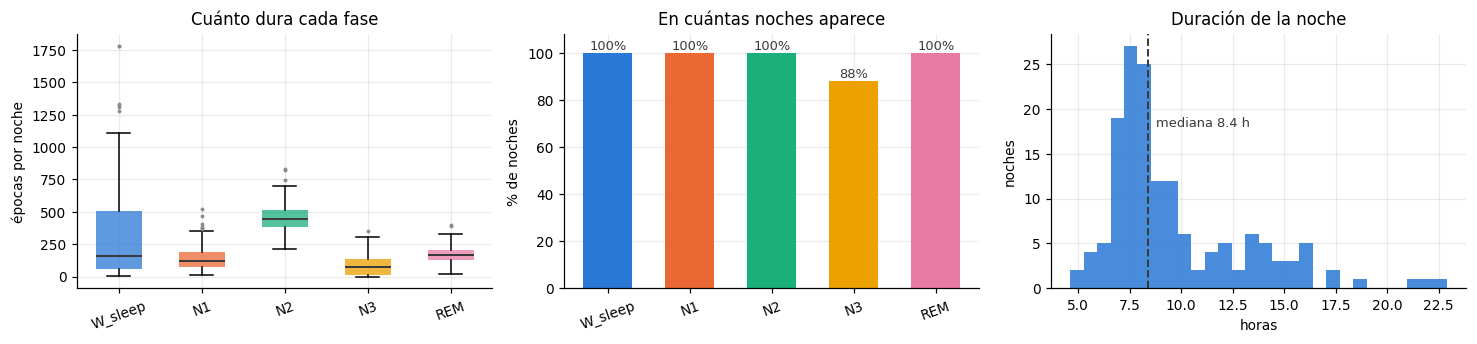

In [14]:
fig, ejes = plt.subplots(1, 3, figsize=(13.5, 3.2))

bp = ejes[0].boxplot([noches[f"n_epocas_{f}"] for f in FASES], labels=FASES,
                     patch_artist=True, widths=.55,
                     medianprops=dict(color=TINTA, lw=1.3),
                     flierprops=dict(marker="o", ms=2.5, mfc=GRIS, mec="none"))
for caja, f in zip(bp["boxes"], FASES):
    caja.set(facecolor=COLOR[f], alpha=.75, edgecolor="none")
ejes[0].set(ylabel="épocas por noche", title="Cuánto dura cada fase")
ejes[0].tick_params(axis="x", rotation=20)

pres = [noches[f"has_{f}"].mean()*100 for f in FASES]
ejes[1].bar(FASES, pres, .6, color=[COLOR[f] for f in FASES])
for i, v in enumerate(pres):
    ejes[1].text(i, v+1.5, f"{v:.0f}%", ha="center", fontsize=8.5, color=TINTA)
ejes[1].set(ylabel="% de noches", ylim=(0, 108), title="En cuántas noches aparece")
ejes[1].tick_params(axis="x", rotation=20)

horas = noches.n_epocas_periodo * EPOCA_S / 3600
ejes[2].hist(horas, bins=28, color="#2a78d6", alpha=.85)
ejes[2].axvline(horas.median(), color=TINTA, ls="--", lw=1.3)
ejes[2].annotate(f"mediana {horas.median():.1f} h", xy=(horas.median()+.4, 18),
                 fontsize=8.5, color=TINTA)
ejes[2].set(xlabel="horas", ylabel="noches", title="Duración de la noche")

plt.tight_layout(); plt.show()

**N3 falta en el 12 % de las noches.** No es un fallo: los mayores no llegan a sueño
profundo. Por eso se guarda `has_N3` en vez de taparlo.

## El dataframe final

In [15]:
noches.shape

(153, 97)

In [16]:
print(f"{len(noches)} filas (una por NOCHE) x {noches.shape[1]} columnas")
print(f"{noches.subject.nunique()} sujetos, {noches.groupby('subject').size().value_counts().to_dict()}")

noches[["subject", "night", "age", "n_epocas_periodo",
        "mix_rel_sigma", "rel_sigma_N2", "rel_sigma_N3",
        "has_N3", "horas_dormidas", "eficiencia", "pct_sueno_en_N1"]].head(10)

153 filas (una por NOCHE) x 97 columnas
78 sujetos, {2: 75, 1: 3}


,subject,night,age,n_epocas_periodo,mix_rel_sigma,rel_sigma_N2,rel_sigma_N3,has_N3,horas_dormidas,eficiencia,pct_sueno_en_N1
0,0,1,33,721,0.007485,0.018066,0.003991,1,5.441667,0.905687,8.882083
1,0,2,33,1008,0.011620,0.025085,0.005402,1,7.866667,0.936508,6.250000
2,1,1,33,983,0.014139,0.021810,0.004887,1,7.883333,0.962360,11.522199
3,1,2,33,1066,0.013985,0.021258,0.005596,1,8.533333,0.960600,8.984375
4,2,1,26,905,0.010399,0.014528,0.003162,1,7.475000,0.991160,10.479376
5,2,2,26,890,0.008543,0.014280,0.003118,1,7.366667,0.993258,20.814480
6,3,1,26,832,0.033504,0.044606,0.008302,1,6.766667,0.975962,7.512315
7,3,2,26,791,0.043889,0.076002,0.015592,1,6.458333,0.979772,5.806452
8,4,1,34,1116,0.043370,0.066337,0.016579,1,8.625000,0.927419,16.038647
9,4,2,34,1084,0.035090,0.059518,0.018111,1,8.458333,0.936347,13.497537


El sujeto 0 tiene **dos filas con la misma edad**: la etiqueta es de la persona, no
de la noche. El notebook `02` las promedia para dejar 78 filas, una por sujeto.

Compara `mix_rel_sigma` con `rel_sigma_N2` en cualquier fila: el segundo siempre es
mayor. Esa es la diferencia que el experimento pone a prueba.